## Modules & Packages

In [1]:
print('Importing relevant modules ...')
# general modules
import warnings
warnings.filterwarnings('ignore')
import sys, os
import numpy as np
import healpy as hp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pylab import rcParams
from matplotlib import rc;rc('text', usetex=True);rc('font', weight='bold');matplotlib.rcParams['text.latex.preamble']
rcParams['axes.facecolor'] = 'white'
rcParams['font.family'] = 'serif'
rc('text.latex',preamble=r'\usepackage{/sptlocal/user/kevinlevy/summerfield_lensing/notebooks/apjfonts}')
from matplotlib import gridspec
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u

import sys, os
sys.path.append("/sptlocal/user/kevinlevy/spt3g_software/build/")
sys.path.append("/sptlocal/user/kevinlevy/spt3g_software/mapspectra/python")
from spt3g import core, maps

Importing relevant modules ...


## Parameters

In [2]:
sim_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/sims/skies/maps/'
sim_file = 'mockobsinput_tqu1_agora0.7_datamatched_mcmccal_0707231033_%sghz_seed1_nside2048.fits'

cls_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/sims/skies/spectra/'
cls_file = 'cls_mockobsinput_tqu1_agora0.7_datamatched_mcmccal_0707231033_%s_%sghz_seed1_nside2048.npy'
cl_theory_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/sims/cmb/spectra/'
cl_theory_file = 'planck2018_base_plikHM_TTTEEE_lowl_lowE_lensing_lensedCls.dat'
fg_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/sims/foregrounds/spectra/'
fg_file = 'cls_allfg%s_allfg%s.dat'

beam_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/'
beam_file = 'compiled_2020_beam_freqghz.npy'

noise_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/sims/noise/maps/fieldname/full/'
noise_file = 'freqghz_seedval.fits'

field_arr = ['summer-a', 'summer-b', 'summer-c']
ps_mask_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/data/masks/'
ps_mask_file = 'apod_mask_45arcmin_field.fits'
apod_ps_mask_dic = {}
for field in field_arr:
    apod_ps_mask = hp.read_map(ps_mask_loc+ps_mask_file.replace('field', field))
    apod_ps_mask[apod_ps_mask == hp.UNSEEN] = 0.
    apod_ps_mask_dic[field] = apod_ps_mask


freq_arr = [90, 150, 220]
title_arr = ['Summer-A', 'Summer-B', 'Summer-C']
sky_frac_arr = [0.032, 0.015, 0.022]

fontsize = 20
color_arr = ['lightseagreen', 'darkorchid',  'goldenrod', 'lightskyblue', 'dimgray']
nbr_pix_dic = {"summer-a":[2200, 1750], "summer-b":[2200, 1750], "summer-c":[3250, 2725]}
cntr_dic = {"summer-a":[75, -46.75], "summer-b":[25, -36], "summer-c":[187.5, -38.5]}
ra_dic = {'summer-a':[50, 62.5, 75, 87.5, 100], 
          'summer-b':[0, 12.5, 25, 37.5, 50], 
          'summer-c':[150, 168.75, 187.5, 206.25, 225]}
dec_dic = {'summer-a':[-63,-56, -49, -42, -35, -31.5, -28, -21], 
           'summer-b':[-42, -38.5, -35, -31.5, -28], 
           'summer-c':[-42, -38.5, -35, -31.5, -28]}
reso_arcmin = 1
axis_label_arr = [['RA', 'DEC'], ['RA', ' '], ['RA', ' ']] 
origin_arr = ['lower', 'lower', 'lower']
title_dic = {'summer-a':'Summer-A', 'summer-b':'Summer-B', 'summer-c':'Summer-C'}
figures_dir = '/sptlocal/user/kevinlevy/summerfield_lensing/figures/sims/'

## Skies

In [3]:
map_arr = []
for freq in freq_arr:
    maps = hp.read_map(sim_loc+sim_file %(freq), field=(0))
    map_arr.append(maps)

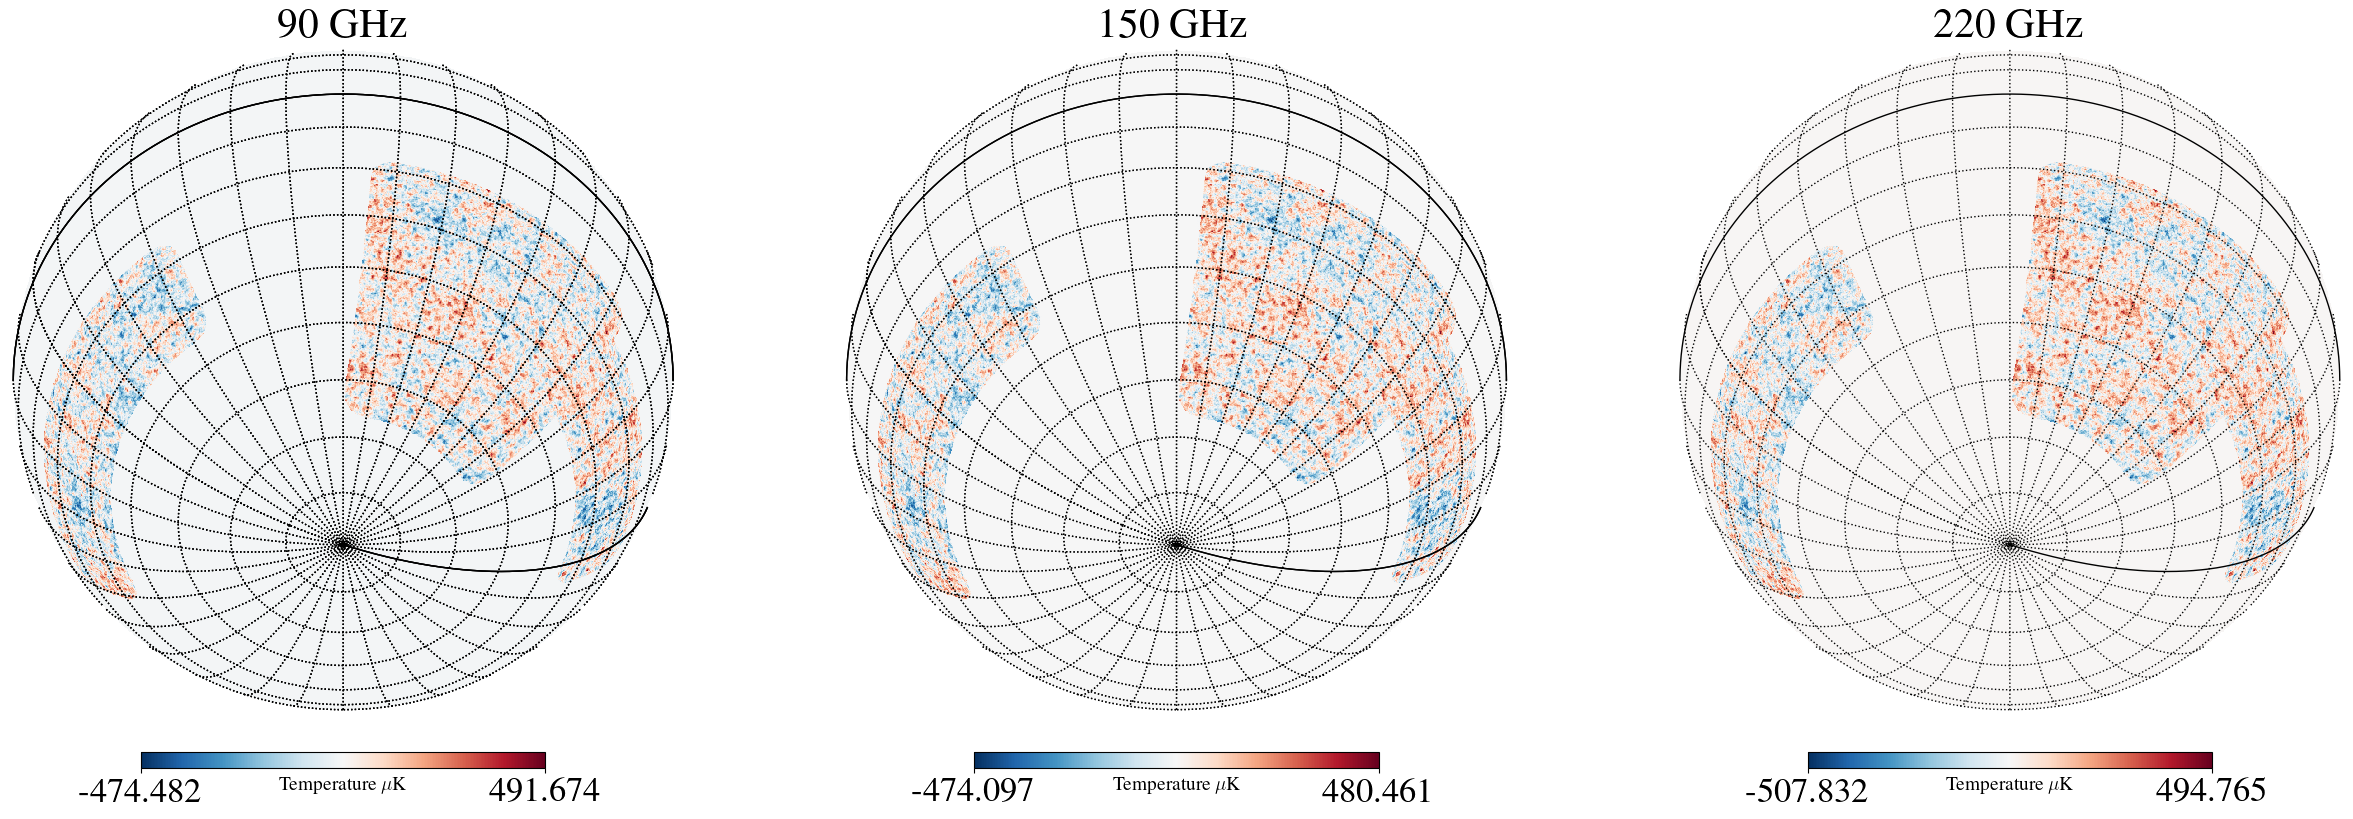

In [4]:
matplotlib.rcParams.update({'font.size':25})
plt.figure(figsize=(25, 8))
for i, freq in enumerate(freq_arr):
    hp.orthview(map_arr[i] , title='%s GHz' %(freq), unit=r" Temperature $\mu$K", sub=(1,3, i+1), badcolor='white', coord='C', half_sky=True, rot=(110, -60, 0), notext=True, cmap=cm.RdBu_r)
    hp.graticule(dpar=10, dmer=10, coord='C')
plt.savefig(figures_dir+'skies.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


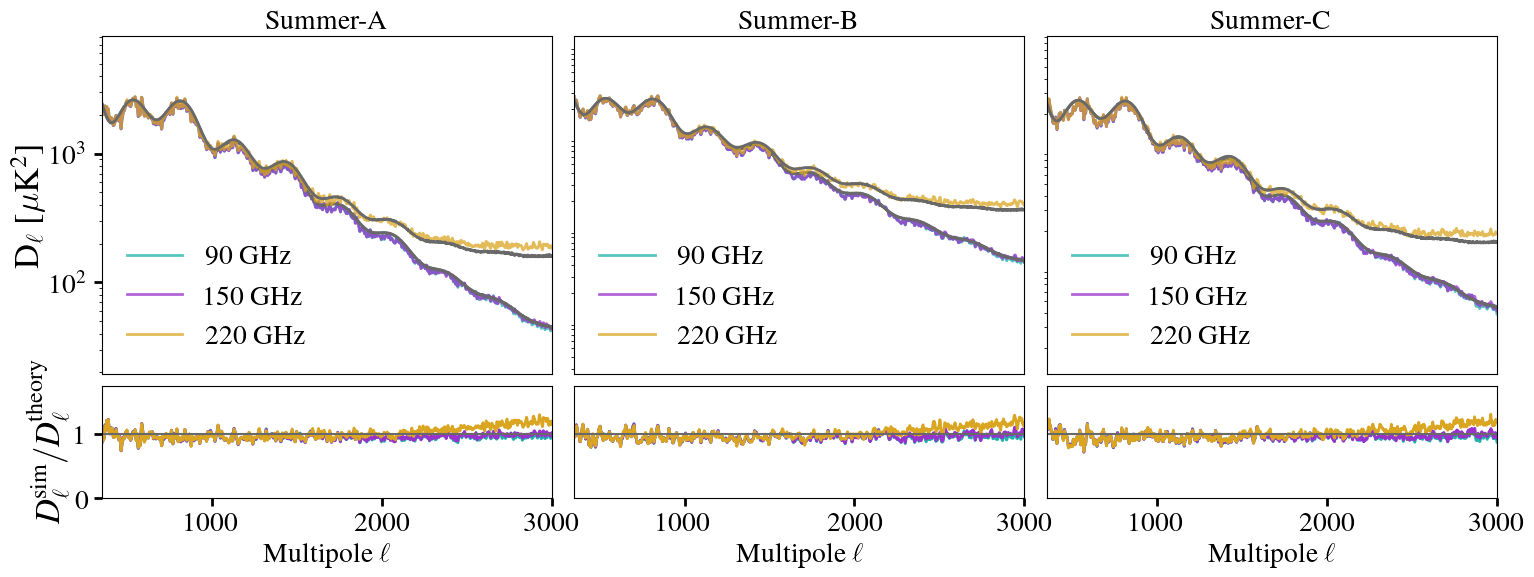

In [5]:
nside=2048
lmax = 2 * nside 
pixwin = hp.pixwin(8192)[:lmax]

fig, ax_arr = plt.subplots(ncols=3, nrows=2, figsize = (18,6), constrained_layout=True, gridspec_kw={'height_ratios':[3,1]}) 
plt.subplots_adjust(hspace=0.05, wspace=0.05)

for cntr, field in enumerate(field_arr):
    for frq_cntr, freq in enumerate(freq_arr):   
        blv2 = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/compiled_2020_beam_%sghz.npy'%(freq))[:lmax]

        curr_binned_cl =  np.load(cls_loc+'cls_mockobsinput_tqu1_agora0.7_datamatched_mcmccal_0707231033_%s_%sghz_seed1_nside2048.npy'%(field, freq))[:lmax]    
        binned_el = np.arange(len(curr_binned_cl))
        binned_dl_fac = binned_el * (binned_el+1)/2/np.pi

        cls_fid = np.loadtxt(cl_theory_loc+cl_theory_file).T[1][:lmax]/binned_dl_fac[:lmax]
        fg_power = np.loadtxt(fg_loc+'cls_allfg%s_allfg%s.dat'%(freq, freq)).T[1][:lmax] 
        
        ax_arr[0][cntr].plot(binned_el[:lmax], binned_dl_fac[:lmax] *curr_binned_cl/blv2**2/sky_frac_arr[cntr], lw=2, color = color_arr[frq_cntr], label =  str(freq) + ' GHz', alpha=0.75)
        ax_arr[0][cntr].plot(binned_el[:lmax], binned_dl_fac[:lmax]*(cls_fid+fg_power), lw=2, color = color_arr[-1])
        
    ax_arr[0][cntr].tick_params(labelsize = fontsize, length = 6, width = 2)
    ax_arr[0][cntr].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)     
    ax_arr[0][cntr].set_yscale('log')
    ax_arr[0][cntr].set_xlim(350, 3000) 
    ax_arr[0][cntr].legend(fontsize=fontsize, frameon=False, loc='lower left')
    ax_arr[0][cntr].set_title(title_arr[cntr], fontsize=fontsize) 
    #ax_arr[0][cntr].set_ylim(1e1, 1e4)
    if cntr==0:        
        ax_arr[0][cntr].set_ylabel(r'D$_{\ell}$ [$\mu$K$^{2}$]', fontsize=fontsize+5)
    else:
        ax_arr[0][cntr].tick_params(direction='out', axis='y', length=6, width=2, which = 'major', left = False, right = False, labelsize = fontsize, labelleft=False)

for cntr, field in enumerate(field_arr):
    for frq_cntr, freq in enumerate(freq_arr):    
        blv2 = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/compiled_2020_beam_%sghz.npy'%(freq))[:lmax]

        curr_binned_cl =  np.load(cls_loc+'cls_mockobsinput_tqu1_agora0.7_datamatched_mcmccal_0707231033_%s_%sghz_seed1_nside2048.npy'%(field, freq))[:lmax]   

        cls_fid = np.loadtxt(cl_theory_loc+cl_theory_file).T[1][:lmax]/binned_dl_fac[:lmax]
        fg_power = np.loadtxt(fg_loc+'cls_allfg%s_allfg%s.dat'%(freq, freq)).T[1][:lmax] 
        
        ax_arr[1][cntr].plot(binned_el[:lmax], (curr_binned_cl/sky_frac_arr[cntr]/blv2**2)/(cls_fid+fg_power), lw=2, color = color_arr[frq_cntr])
    
    ax_arr[1][cntr].tick_params(labelsize = fontsize, length = 6, width = 2)    
    ax_arr[1][cntr].axhline(1, color=color_arr[-1])
    ax_arr[1][cntr].set_xlim(350, 3000) 
    ax_arr[1][cntr].set_xlabel(r'Multipole $\ell$', fontsize=fontsize)
    ax_arr[1][cntr].legend(fontsize=fontsize-2, frameon=False)
    ax_arr[1][cntr].set_ylim(0., 1.75)
    if cntr==0:
        ax_arr[1][cntr].set_ylabel(r'$D_\ell^{\rm sim}/D_\ell^{\rm theory}$', fontsize=fontsize+5)
    else:
        ax_arr[1][cntr].tick_params(direction='out', axis='y', length=6, width=2, which = 'major', left = False, right = False, labelsize = fontsize, labelleft=False)        

plt.savefig(figures_dir+'skies_spectra.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

## Mocks

In [6]:
def read_map_frame(path, id=None):
    if path.split(".")[-1] == 'g3' or path.split(".")[-1] == 'gz': 
        for frame in core.G3File(path): 
            return frame


mock_arr = []
for freq in freq_arr:
    mock = np.asarray(read_map_frame('/sptlocal/user/kevinlevy/summerfield_lensing/sims/mocks/coadds/maps/coadd_tqu1_agora0.7_datamatched_mcmccal_0707231033_summerall_%sghz_seed1.g3' %(freq))['T'])
    mock_arr.append(mock)

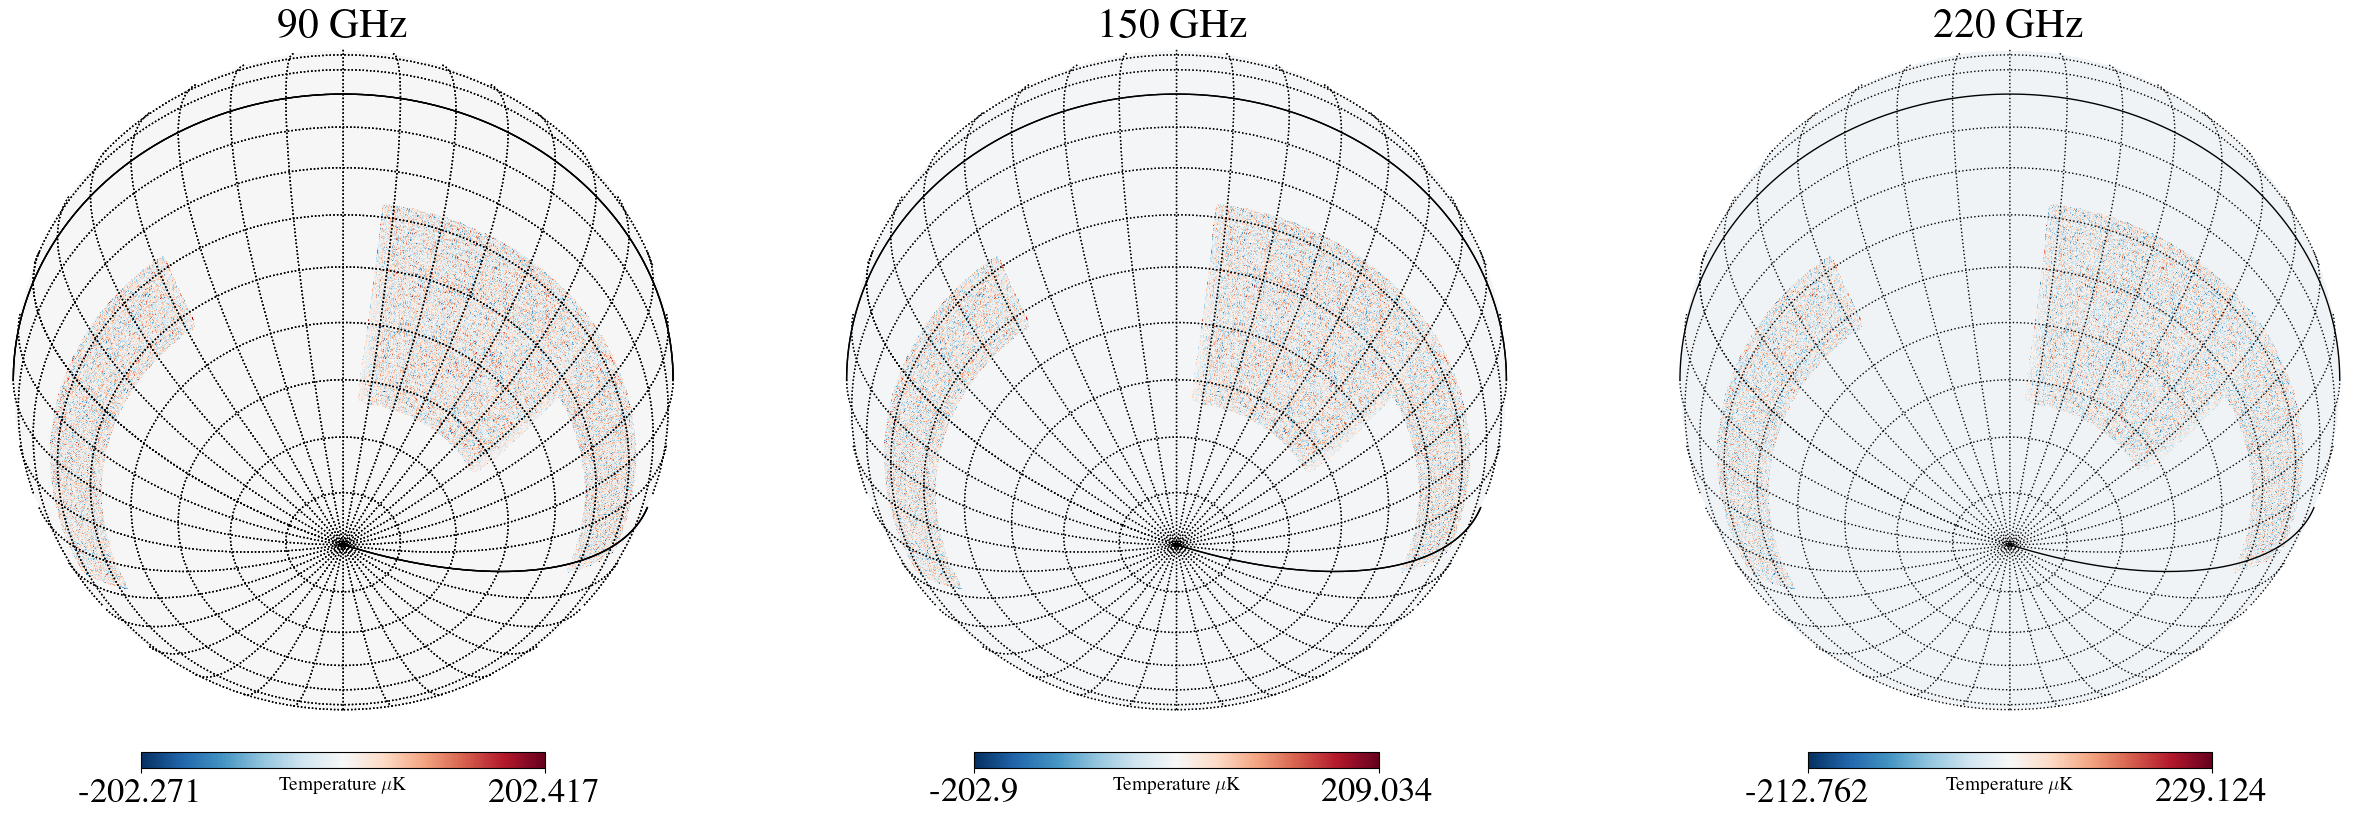

In [7]:
plt.figure(figsize=(25, 8))
for i, freq in enumerate(freq_arr):
    hp.orthview(mock_arr[i] , title='%s GHz' %(freq), unit=r" Temperature $\mu$K", sub=(1,3, i+1), badcolor='white', coord='C', half_sky=True, rot=(110, -60, 0), notext=True, cmap=cm.RdBu_r)
    hp.graticule(dpar=10, dmer=10, coord='C')
plt.savefig(figures_dir+'mocks.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

In [8]:
import curved_sky 

def get_cl_from_polspice(m1, m2 = None, mask = None, bl1 = None, bl2 = None, 
                         lmin = 0, lmax = 4500, bin_width = 1, 
                         return_mask = False, return_error = False, return_kernel = False,
                         pixwin = 'NO', pixwin_lab = 'False', lfac = 0, 
                         verbose = True, symmetric_cl = 0, apodizetype = 1, 
                         apodizesigma = 30, thetamax = 30, tolerance = 1.e-08):
    
    binned_el, binned_cl = curved_sky.spectrum_spice(
            map1=m1, 
            map2=m2, 
            lmin=lmin, 
            lmax=lmax, 
            bin_width=bin_width,
            return_mask=return_mask,
            mask=mask,
            return_error=return_error,
            return_kernel=return_kernel, 
            lfac=lfac, 
            verbose=verbose,
            beam=bl1,
            pixwin=pixwin,
            beam2=bl2,
            pixwin2=pixwin,
            symmetric_cl=symmetric_cl,
            apodizetype=apodizetype,
            apodizesigma=apodizesigma,
            thetamax=thetamax,
            tolerance=tolerance)

    return binned_el, binned_cl

binned_el, binned_cl = get_cl_from_polspice(mock_arr[1])

setting the output map dtype to [dtype('float64')]


 ===> Using HEALPIXDATA=/cvmfs/spt.opensciencegrid.org/py3-v4/RHEL_9_x86_64/share/healpix/

 SpICE 3.7.5_DP has been called with the following attributes : 

 nside detected...         2048
 max multipole used        4500
 polarization..... NO
 map file (1)......
     1.000 *   /tmp/tmp99vb35mr/map.fits
 mask file....(T)..NO
 weight file..(T)..NO
 weight power.....    1.0000000000000000     
 dump alm(1)...... NO
 weight alm(1).... NO
 gauss beam arcmin NO
 beam file........ NO
 pix. window file. NO
 subtract dipole.. NO
 subtract average. NO
 cor. file........ NO
 Cl file.......... /tmp/tmp99vb35mr/cl.fits
 Covariance file.. NO
 raw Cl map output NO
 raw Cl map input  NO
 raw Cl mask outp. NO
 raw Cl mask inpu. NO
 FITS output...... YES
 norm. factor..... NO
 apodizing width..     3.00000E+01
 apodizing type...            1
 decouple......... NO
 thetamax.........    30.000000000000000     
 kernels output... NO
 window output.... NO
 window input..... NO
 TE norm output... NO
 TE nor

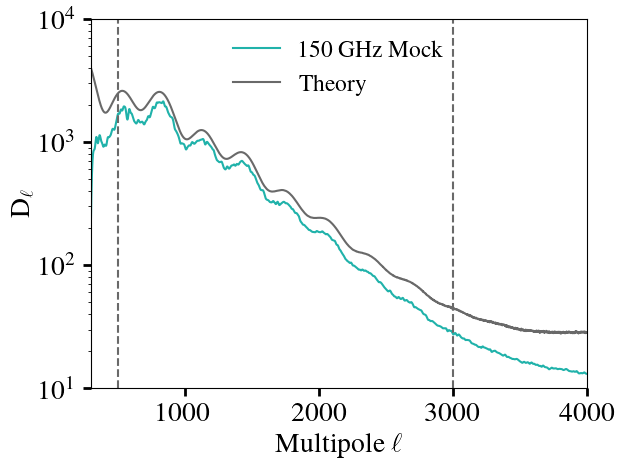

In [9]:
lmax=4500
ell = np.loadtxt(cl_theory_loc+cl_theory_file, unpack=True)[0][:lmax]
dl_fac = 2.0*np.pi/(ell**2+ell)[:lmax]
cls_fid = np.loadtxt(cl_theory_loc+cl_theory_file).T[1][:lmax]*dl_fac


tr, tc = 3, 3
sbpl = 1
beam_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/'
beam_file = 'compiled_2020_beam_freqghz.npy'
bl = np.load(beam_loc+beam_file.replace('freq', str(150)))[:4500]
pixwin=hp.pixwin(2048)[:4500]
fg_power = np.loadtxt(fg_loc+'cls_allfg%s_allfg%s.dat'%(150, 150)).T[1][:lmax] 

matplotlib.rcParams.update({'font.size':15})
plt.plot(binned_el, binned_cl/0.067/dl_fac, color = color_arr[0], label='150 GHz Mock', lw = 1.5)
plt.plot(np.arange(len(cls_fid)), (cls_fid+fg_power)/dl_fac, color=color_arr[-1], label='Theory', lw = 1.5)
plt.legend(frameon=False, fontsize=fontsize-3, loc = 'upper center')
plt.axhline(0, color='k')
plt.xlabel(r'Multipole $\ell$', fontsize=fontsize)
plt.ylabel(r'D$_{\ell}$', fontsize=fontsize)
plt.yscale('log')
plt.ylim(1e1, 1e4)
plt.xlim(300, 4000)
plt.axvline(500, ls='--', color=color_arr[-1])
plt.axvline(3000, ls='--', color=color_arr[-1])
plt.tick_params(labelsize = fontsize, length = 6, width = 2)    

plt.savefig(figures_dir+'mock_spectra.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

## Transfer Functions

In [10]:
def get_alm_on_a_grid(alm, lmax = 4000, mmax = 4000):
    n = len(alm)
    lmax_for_alm = hp.Alm.getlmax(n)
    assert lmax <= lmax_for_alm

    ell_arr, emm_arr = np.arange(lmax), np.arange(mmax)
    alm_grid = np.zeros (( len(emm_arr), len(ell_arr) ))
    for emm in emm_arr:
        for ell in ell_arr:
            if emm>ell: continue
            curr_alm_ind = hp.Alm.getidx( lmax_for_alm, ell, emm ) 
            alm_grid[emm, ell] = alm[curr_alm_ind]

    return alm_grid, ell_arr, emm_arr

def read_map_frame(path, id=None):
    """
    Return first map frame in .g3/.fits file located at `path`.
    """
    if not os.path.exists(path):
        raise OSError("File {} does not exist".format(path))

    if path.split(".")[-1] == 'g3': 
        for frame in core.G3File(path): 
            if frame.type == core.G3FrameType.Map:
                return frame
        raise RuntimeError("Map frame {} not found G3File.".format(id))
    elif path.split(".")[-1] == 'fits':
        return maps.fitsio.load_skymap_fits(path)

    raise OSError("G3File {} does not contain a map frame .".format(path))

field_arr = ['summer-a', 'summer-b', 'summer-c']
freq_arr = [90, 150, 220]
nside_input = 8192
nside_output = 2048
pixwin_input = hp.pixwin(nside_input)
pixwin_output = hp.pixwin(nside_output)

tf2d_dic = {}
tf1d_dic = {}
cls_input_dic = {}
cls_mock_dic = {}
cls_mock_tf1d_dic = {}
cls_mock_tf2d_dic = {}

for field in field_arr:
    tf2d_dic[field] = {}
    tf1d_dic[field] = {}
    cls_input_dic[field] = {}
    cls_mock_dic[field] = {}
    cls_mock_tf1d_dic[field] = {}
    cls_mock_tf2d_dic[field] = {}
    
    for freq in freq_arr:
        dir_out = '/sptlocal/user/kevinlevy/summerfield_lensing/sims/mocks/tfs/%s/' %(field)
        tf2d = np.load(dir_out+ 'tf2d_%sghz_250sims.npz'%(freq))
        tf2d_dic[field][freq] = np.asarray(tf2d['tf2d']).real[0]
        tf1d = np.load(dir_out+ 'tf1d_%sghz_100sims.npy'%(freq))
        tf1d_dic[field][freq] = np.asarray(tf1d)

        cls_input = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/sims/skies/spectra/cls_mockobsinput_tqu1_agora0.7_datamatched_mcmccal_0707231033_%s_%sghz_seed1_nside2048.npy'%(field, freq))
        cls_input_dic[field][freq] =  cls_input[:5000]/pixwin_output[:5000]**2
             
        alms_mock = hp.read_alm("/sptlocal/user/kevinlevy/summerfield_lensing/sims/mocks/coadds/maps/coadd_tqu1_agora0.7_datamatched_mcmccal_0707231033_%s_%sghz_seed1.alm" %(field, freq))
        alms_mock_tf2d = alms_mock/tf2d_dic[field][freq]
        cls_mock_tf2d_dic[field][freq] = hp.alm2cl(alms_mock_tf2d)[:5000]/(pixwin_output[:5000]*pixwin_input[:5000]**2)**2

        cls_mock = np.load("/sptlocal/user/kevinlevy/summerfield_lensing/sims/mocks/coadds/spectra/cls_coadd_tqu1_agora0.7_datamatched_mcmccal_0707231033_%s_%sghz_seed1.npy" %(field, freq))
        cls_mock_dic[field][freq] = cls_mock[:5000]/(pixwin_output[:5000]*pixwin_input[:5000]**2)**2
        cls_mock_tf1d_dic[field][freq] = cls_mock[:5000]/(pixwin_output[:5000]*pixwin_input[:5000]**2)**2/tf1d_dic[field][freq][:5000]

tf_2d_grid, ell_arr, emm_arr = get_alm_on_a_grid( np.asarray(tf2d['tf2d']).real[0], lmax = 4000, mmax = 4000)

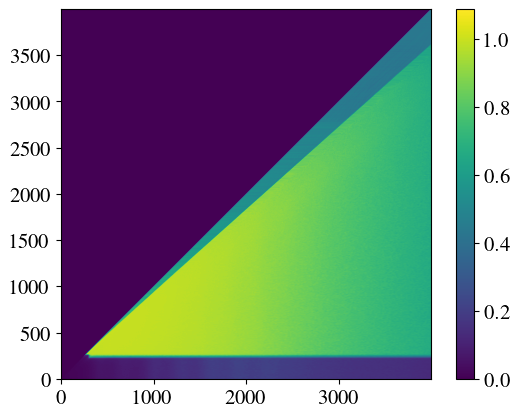

In [11]:
plt.imshow(tf_2d_grid, origin='lower', extent=[np.min(ell_arr), np.max(ell_arr), np.min(emm_arr), np.max(emm_arr)])
plt.colorbar()
plt.savefig(figures_dir+'transfer_functions_2d.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

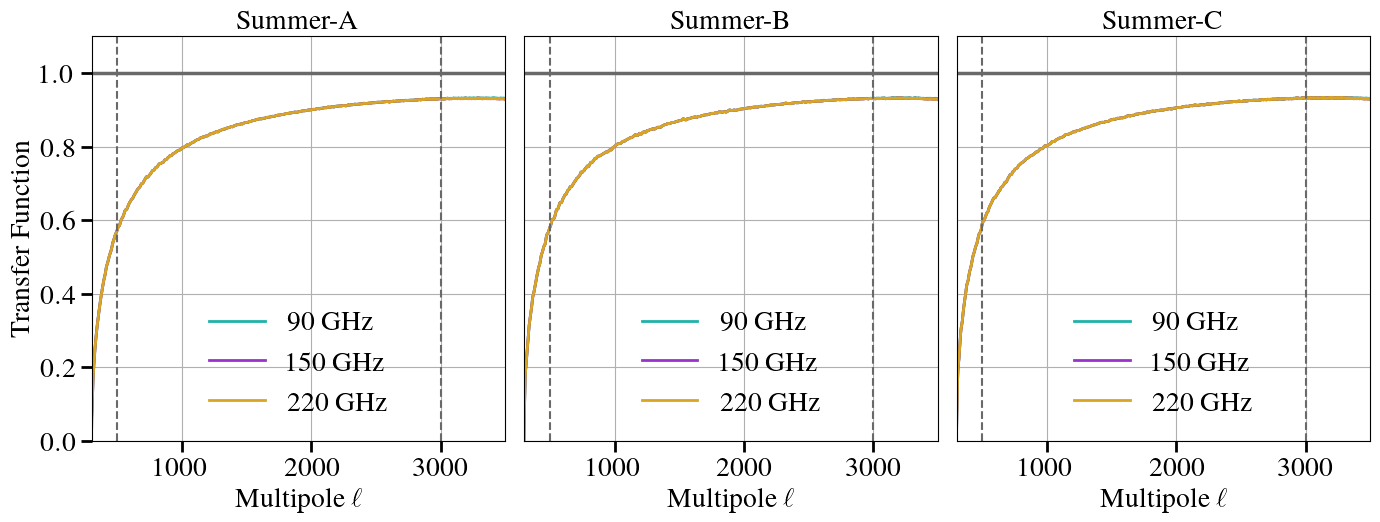

In [12]:
pixwin = hp.pixwin(8192)[:4096]
title_arr = []
null_test_name_arr = ['full']
nside=2048
lmax = 2 * nside 
band_keyname_arr = [('90GHz', '90GHz'), ('150GHz', '150GHz'),('220GHz', '220GHz')]
ls_arr = ['-', '-', '-']
title_arr = ["Summer-A", "Summer-B", "Summer-C"]

fig, ax_arr = plt.subplots(1, len(title_arr), sharey=True, figsize=(16.5,5.25))
plt.subplots_adjust(hspace=0.2, wspace = 0.045)

for cntr, field in enumerate(field_arr):
    for frq_cntr, freq in enumerate(freq_arr):    
        ax_arr[cntr].plot(tf1d_dic[field][freq], color = color_arr[frq_cntr], ls = ls_arr[frq_cntr], lw=2, label = '%s GHz' %(freq))
        
    ax_arr[cntr].axhline(1, color = color_arr[-1], ls = '-', lw=2.5)
    ax_arr[cntr].grid()

    #ax_arr[cntr].axhline(0.8, color = color_arr[-1], ls = '--', lw=1.5)
    #ax_arr[cntr].axhline(0.9, color = color_arr[-1], ls = '--', lw=1.5)
    ax_arr[cntr].axvline(500, color = color_arr[-1], ls = '--', lw=1.5)
    ax_arr[cntr].axvline(3000, color = color_arr[-1], ls = '--', lw=1.5)
    
    ax_arr[cntr].set_xlim(300, 3500) 
    ax_arr[cntr].set_xlabel(r'Multipole $\ell$', fontsize=fontsize)
    ax_arr[cntr].legend(fontsize=fontsize, frameon=False, loc='lower center')
    ax_arr[cntr].set_title(title_arr[cntr], fontsize=fontsize) 

    ax_arr[cntr].tick_params(which='major', labelsize = fontsize, length = 8, width = 2)
    ax_arr[cntr].tick_params(which='minor', labelsize = fontsize, length = 4, width = 1)
    
    if cntr==0:
        ax_arr[cntr].set_ylim(0, 1.1)
        ax_arr[cntr].set_ylabel('Transfer Function', fontsize=fontsize)
    else:
        ax_arr[cntr].tick_params(axis='y', which='major', length = 0, width = 0)
        ax_arr[cntr].tick_params(axis='y', which='minor', length = 0, width = 0)

plt.savefig(figures_dir+'transfer_functions_1d.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

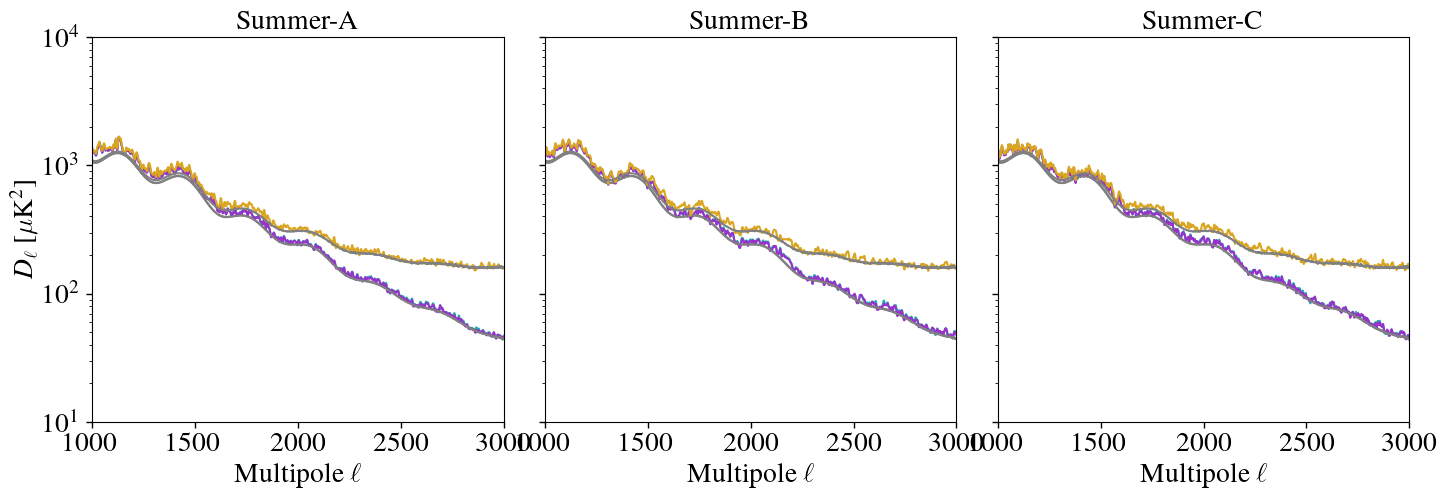

In [13]:
lmax=4500
ell = np.loadtxt(cl_theory_loc+cl_theory_file, unpack=True)[0][:lmax]
dl_fac = 2.0*np.pi/(ell**2+ell)[:lmax]
cls_fid = np.loadtxt(cl_theory_loc+cl_theory_file).T[1][:lmax]*dl_fac

ls_arr = ['-', '--', ':']
fig, ax_arr = plt.subplots(1, len(field_arr), sharey=True, figsize=(17,5))
plt.subplots_adjust(hspace=0.2, wspace = 0.1)

for cntr, field in enumerate(field_arr):
    
    ax_arr[cntr].set_yscale('log')
    
    for frq_cntr, freq in enumerate(freq_arr):    
        blv2 = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/compiled_2020_beam_%sghz.npy'%(freq))[:lmax]
        ax_arr[cntr].plot(ell[:lmax], cls_mock_tf1d_dic[field][freq][:lmax]/dl_fac[:lmax]/sky_frac_arr[cntr]/blv2**2/tf1d_dic[field][freq][:lmax], color = color_arr[frq_cntr], label = '%s GHz'%(freq))
        fg_power = np.loadtxt(fg_loc+'cls_allfg%s_allfg%s.dat'%(freq, freq)).T[1][:lmax] 
        ax_arr[cntr].plot((cls_fid+fg_power)/dl_fac, color='grey')

    ax_arr[cntr].set_xlim(1000, 3000) 
    ax_arr[cntr].set_xlabel(r'Multipole $\ell$', fontsize=fontsize)
    #ax_arr[cntr].legend(fontsize=legendsize, frameon=False)
    ax_arr[cntr].set_title(title_dic[field], fontsize=fontsize) 
    ax_arr[cntr].tick_params(direction='out', axis='x', length=4, width=1, which = 'major', top = False, bottom = True, labelsize = fontsize)
    ax_arr[cntr].tick_params(direction='out', axis='y', length=4, width=1, which = 'major', left = True,right = False, labelsize = fontsize)
    if cntr==0:
        ax_arr[cntr].set_ylim(1e1, 1e4)
        ax_arr[cntr].set_ylabel(r'$D_{\ell}$ [$\mu$K$^{2}$]', fontsize=fontsize)

## Noise

In [14]:
noise_maps_dic = {}
for field in field_arr:
    noise_maps_dic[field] = {}
    for freq in freq_arr:
        noise_map = hp.read_map((noise_loc+noise_file).replace('fieldname', field).replace('freq', str(freq)).replace('seedval', str(1)))
        noise_maps_dic[field][freq] = hp.gnomview(noise_map*1e3, xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True)

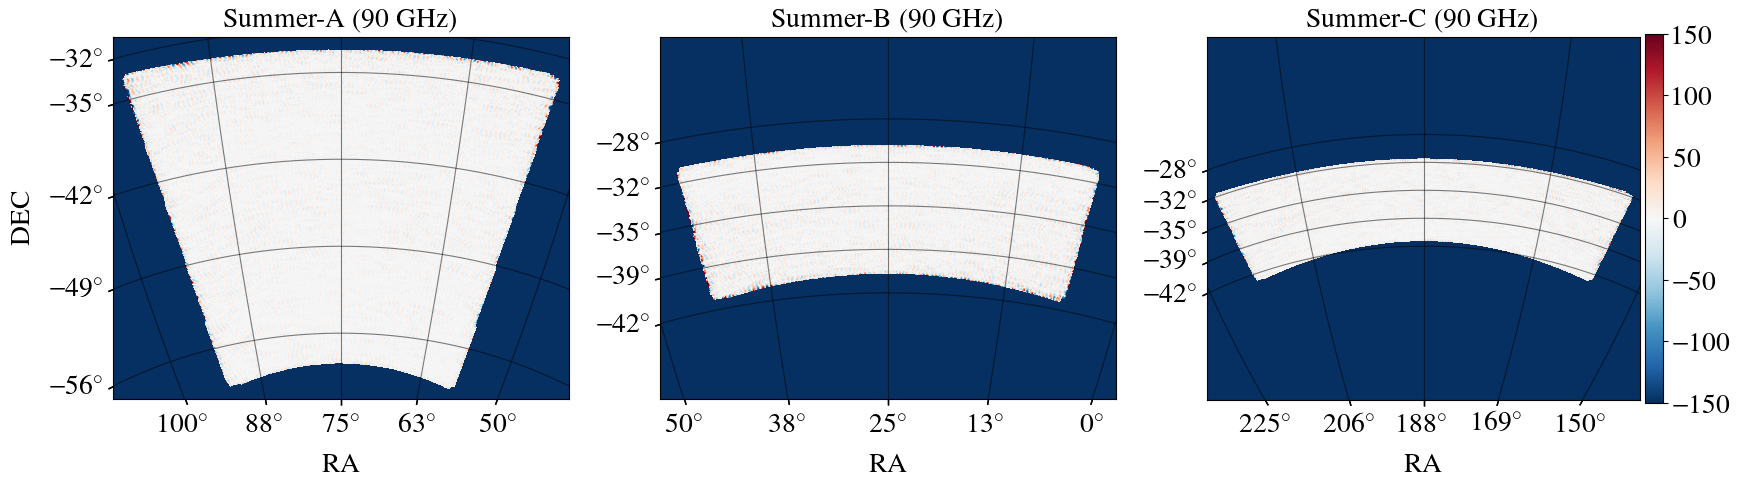

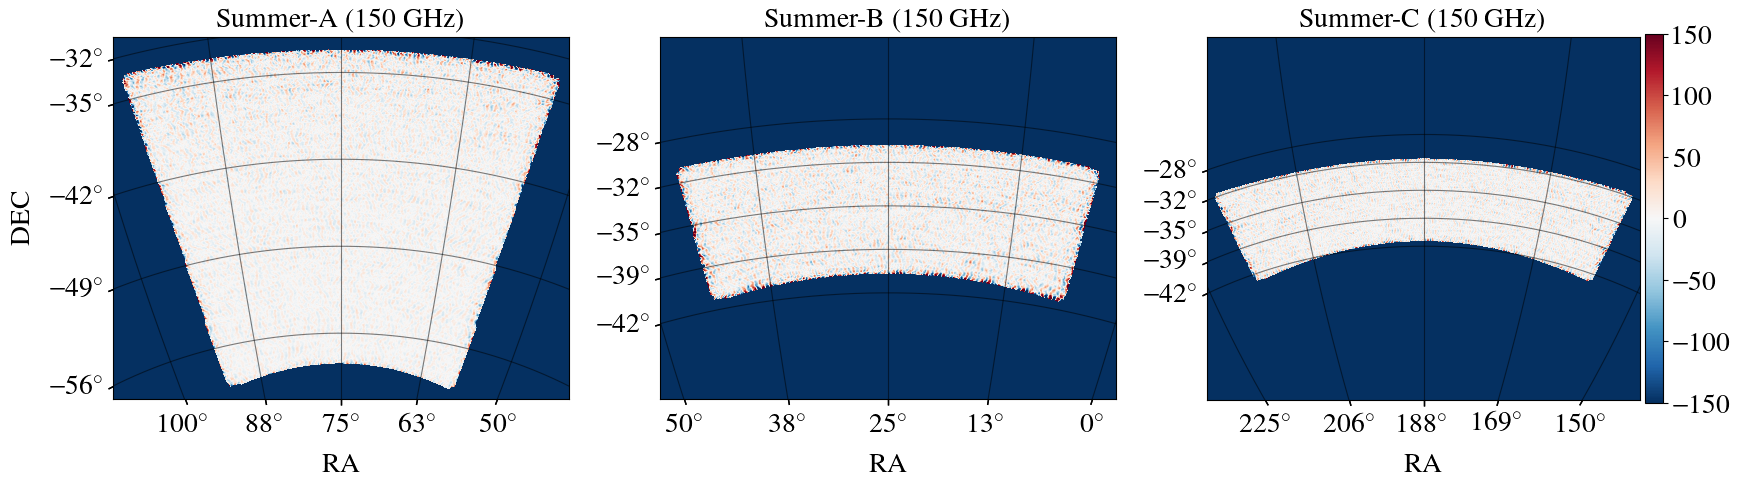

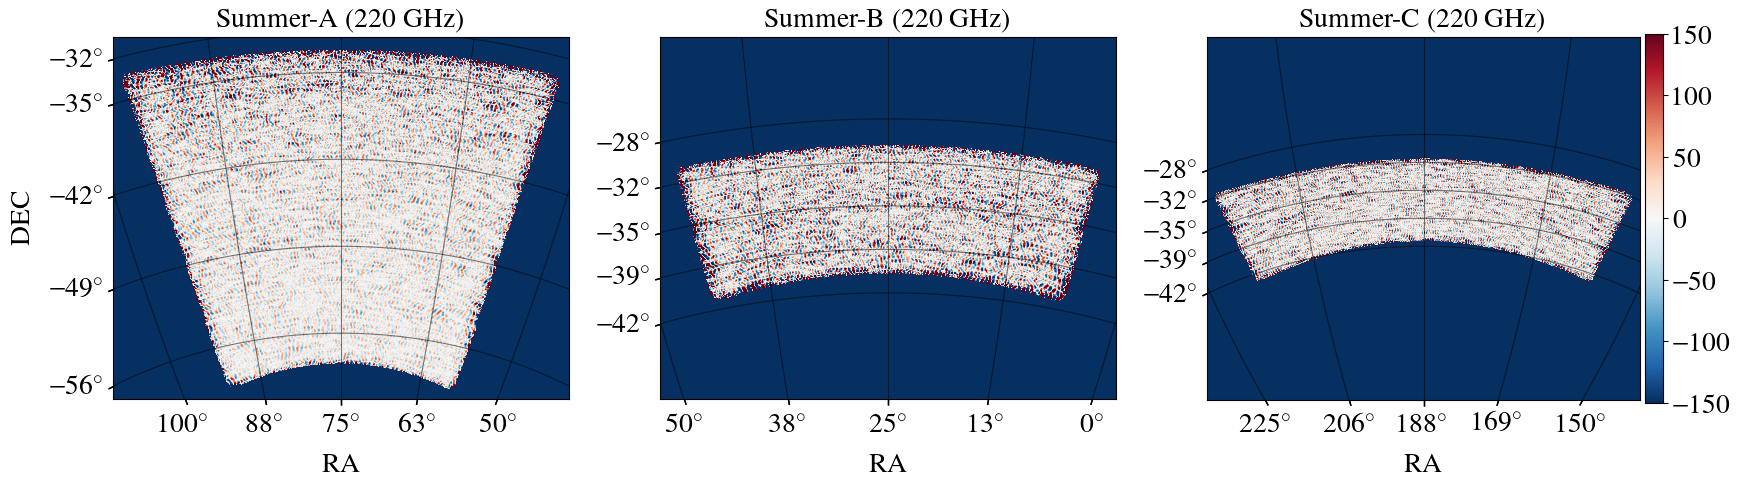

In [15]:
gs  = gridspec.GridSpec(nrows = 1, ncols = 1, hspace=0.0, wspace=0.0, left=0.06, right=0.99, top=0.95, bottom=0.01)

label_arr = ['', '', '']

for freq in freq_arr:
    fig = plt.figure(figsize=(20,15))
    for i, field in enumerate(field_arr):
        
        hdr = fits.Header()
        hdr.set('NAXIS'   , 2)
        hdr.set('NAXIS1'  , nbr_pix_dic[field][0])
        hdr.set('NAXIS2'  , nbr_pix_dic[field][1])
        hdr.set('CTYPE1'  , 'RA---ZEA')
        hdr.set('CRPIX1'  , nbr_pix_dic[field][0]/2)
        hdr.set('CRVAL1'  , cntr_dic[field][0])
        hdr.set('CDELT1'  , -reso_arcmin*0.0166667)
        hdr.set('CUNIT1'  , 'deg')
        hdr.set('CTYPE2'  , 'DEC--ZEA')
        hdr.set('CRPIX2'  , nbr_pix_dic[field][1]/2)
        hdr.set('CRVAL2'  , cntr_dic[field][1]) 
        hdr.set('CDELT2'  , reso_arcmin*0.0166667)
        hdr.set('CUNIT2'  , 'deg')
        hdr.set('COORDSYS','icrs')
        
        w = WCS(hdr)
        ax = plt.subplot(1, len(field_arr), i+1, projection=w)
    
        im = ax.imshow(noise_maps_dic[field][freq], origin=origin_arr[i], vmin=-150, vmax=150, cmap=cm.RdBu_r)
        ax.set_xlabel(axis_label_arr[i][0], fontsize = fontsize)
        ax.set_ylabel(axis_label_arr[i][1], fontsize = fontsize)
        ax.set_title(title_dic[field]+' ('+str(freq)+' GHz)', fontsize = fontsize)
        ax.tick_params(labelsize = fontsize) 
        ax.tick_params(direction='out', axis='x', length=4, width=1, which = 'major', top = False, bottom = True, labelsize = fontsize)
        ax.tick_params(direction='out', axis='y', length=4, width=1, which = 'major', left = True,right = False, labelsize = fontsize)
        ax.grid(color='black', ls='solid',alpha=0.5)
        if i==len(field_arr)-1:
            cb = fig.colorbar(im, ax=ax, orientation="vertical", pad=0.01, fraction=0.0405)
            cb.set_label(label=label_arr[i], fontsize = fontsize)
            cb.ax.tick_params(labelsize=fontsize) 
    
        lon, lat = ax.coords
        lat.set_ticklabel_position('l')
        lon.set_ticklabel_position('b')
        lon.set_ticks(ra_dic[field] * u.degree)
        lon.set_major_formatter('dd')
        lat.set_ticks(dec_dic[field] * u.degree)
        lat.set_major_formatter('dd')

plt.savefig(figures_dir+'noise_sims.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)  

In [16]:
import curved_sky 

def get_cl_from_polspice(m1, m2 = None, mask = None, bl1 = None, bl2 = None, 
                         lmin = 0, lmax = 4096, bin_width = 1, 
                         return_mask = False, return_error = False, return_kernel = False,
                         pixwin = 'NO', pixwin_lab = 'False', lfac = 0, 
                         verbose = True, symmetric_cl = 0, apodizetype = 1, 
                         apodizesigma = 30, thetamax = 30, tolerance = 1.e-08):
    
    binned_el, binned_cl = curved_sky.spectrum_spice(
            map1=m1, 
            map2=m2, 
            lmin=lmin, 
            lmax=lmax, 
            bin_width=bin_width,
            return_mask=return_mask,
            mask=mask,
            return_error=return_error,
            return_kernel=return_kernel, 
            lfac=lfac, 
            verbose=verbose,
            beam=bl1,
            pixwin=pixwin,
            beam2=bl2,
            pixwin2=pixwin,
            symmetric_cl=symmetric_cl,
            apodizetype=apodizetype,
            apodizesigma=apodizesigma,
            thetamax=thetamax,
            tolerance=tolerance)

    return binned_el, binned_cl

for field in field_arr:
    for freq1 in freq_arr:
        for freq2 in freq_arr:
            if freq2<freq1: continue 
            cl_avg_arr = []
            for seed in range(1,51):
                if os.path.exists('/sptlocal/user/kevinlevy/summerfield_lensing/sims/noise/spectra/%s/full/cls_%sghz_%sghz_seed%s.npy'%(field, freq1, freq2, seed)):
                    #print('%s, %s, %s, %s exists!' %(field, freq1, freq2, seed))
                    binned_cl = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/sims/noise/spectra/%s/full/cls_%sghz_%sghz_seed%s.npy'%(field, freq1, freq2, seed))
                else:
                    noise_map1 = hp.read_map((noise_loc+noise_file).replace('fieldname', field).replace('freq', str(freq1)).replace('seedval', str(seed)))
                    noise_map2 = hp.read_map((noise_loc+noise_file).replace('fieldname', field).replace('freq', str(freq2)).replace('seedval', str(seed)))
                    binned_el, binned_cl = get_cl_from_polspice(noise_map1*apod_ps_mask_dic[field],m2= noise_map2*apod_ps_mask_dic[field], mask = apod_ps_mask_dic[field])
                    binned_cl *= 1e6
                    np.save('/sptlocal/user/kevinlevy/summerfield_lensing/sims/noise/spectra/%s/full/cls_%sghz_%sghz_seed%s.npy'%(field, freq1, freq2, seed), binned_cl)
                cl_avg_arr.append(binned_cl)
            cl_avg = np.mean(cl_avg_arr, axis=0)
            np.save('/sptlocal/user/kevinlevy/summerfield_lensing/sims/noise/spectra/%s/full/cls_%sghz_%sghz_avg100.npy'%(field, freq1, freq2), cl_avg)

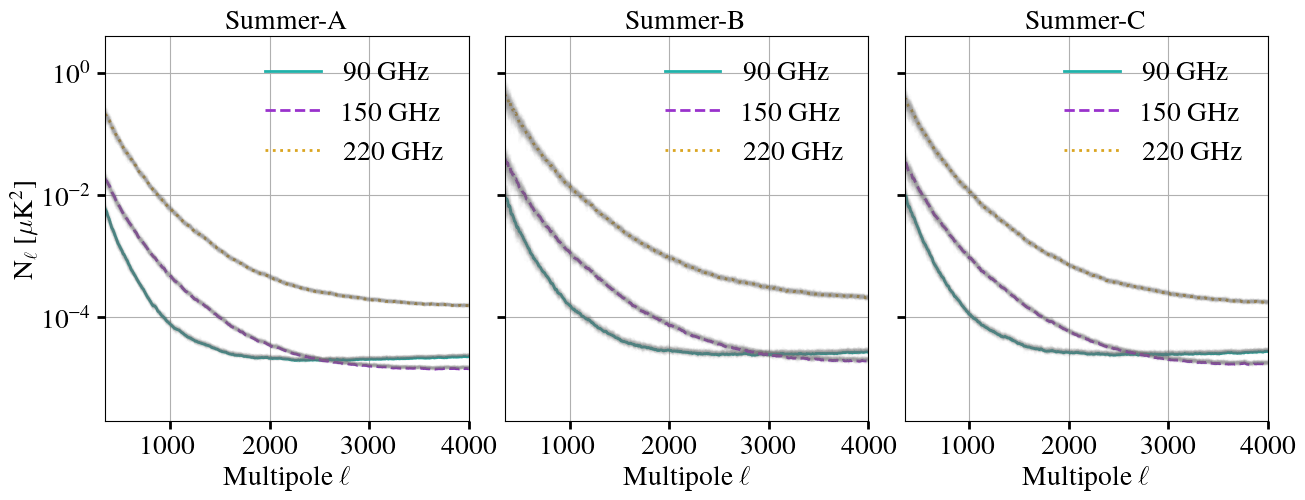

In [17]:
np.seterr(divide = 'ignore') 
nside=2048
lmax = 2 * nside 
pixwin = hp.pixwin(8192)[:lmax]
expectation_arr = [19, 15, 48]
ls_arr = ['-', '--', ':']

fig, ax_arr = plt.subplots(1, len(field_arr), sharey=True, figsize=(15,5))
plt.subplots_adjust(hspace=0.2, wspace = 0.1)

for cntr, field in enumerate(field_arr):
    for frq_cntr, freq in enumerate(freq_arr):    
        blv2 = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/compiled_2020_beam_%sghz.npy'%(freq))[:lmax]
        blv4 = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/B_ell.npz')[str(freq)][:lmax]
        tf1d = np.load("/sptlocal/user/kevinlevy/summerfield_lensing/sims/mocks/tfs/summer-a/tf1d_%sghz_100sims.npy"%(freq))[:lmax]
        
        curr_binned_nl = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/sims/noise/spectra/%s/full/cls_%sghz_%sghz_avg100.npy'%(field, freq, freq))
        curr_binned_el = np.arange(len(curr_binned_nl))
        
        binned_dl_fac = curr_binned_el * (curr_binned_el+1)/2/np.pi 
        ax_arr[cntr].plot(curr_binned_el,  curr_binned_nl/blv4**2/tf1d, color = color_arr[frq_cntr], ls = ls_arr[frq_cntr], lw=2, label = str(freq)+' GHz') 


        #curr_binned_nl = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/coadds/scandir/%s/spectra/cls_full_coadd_%sghz_%sghz.npy'%(field, freq, freq))
        #curr_binned_el = np.arange(len(curr_binned_nl))

        #ax_arr[cntr].plot(curr_binned_el, curr_binned_nl/blv4**2/tf1d, color = color_arr[frq_cntr], ls = ls_arr[frq_cntr], lw=2, label = str(freq)+' GHz') 

        #curr_binned_nl = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/data/coadds/scandir/%s/spectra/cls_full_coadd_%sghz_%sghz.npy'%(field, freq, freq))
        #ax_arr[cntr].plot(curr_binned_el, binned_dl_fac *  curr_binned_nl,  ls = ls_arr[frq_cntr], lw=2, color=color_arr[-1])
        #ax_arr[cntr].plot(curr_binned_el, (binned_dl_fac/binned_dl_fac)*(expectation_arr[frq_cntr]*np.radians(1/60))**2,  ls = ls_arr[frq_cntr], lw=2, color=color_arr[-1])

        for i in range(1,51):
            cl = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/sims/noise/spectra/%s/full/cls_%sghz_%sghz_seed%s.npy'%(field, freq, freq, i))
            ax_arr[cntr].plot(curr_binned_el, cl/blv2**2/tf1d, color='grey', alpha=0.025) 
    
    ax_arr[cntr].set_yscale('log')
    ax_arr[cntr].set_xlim(350, 4000)
    ax_arr[cntr].grid()
    ax_arr[cntr].set_xlabel(r'Multipole $\ell$', fontsize=fontsize)
    ax_arr[cntr].legend(fontsize=fontsize, frameon=False)
    ax_arr[cntr].set_title(title_dic[field], fontsize=fontsize) 
    ax_arr[cntr].tick_params(labelsize = fontsize, length = 6, width = 2)
    #ax_arr[cntr].axvline(3500,  ls = "-.", lw=2, color=color_arr[-1])

    if cntr==0:
        ax_arr[cntr].set_ylim(2e-6, 4e0)
        ax_arr[cntr].set_ylabel(r'N$_{\ell}$ [$\mu$K$^{2}$]', fontsize=fontsize)

plt.savefig(figures_dir+'noise_sims_spectra.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


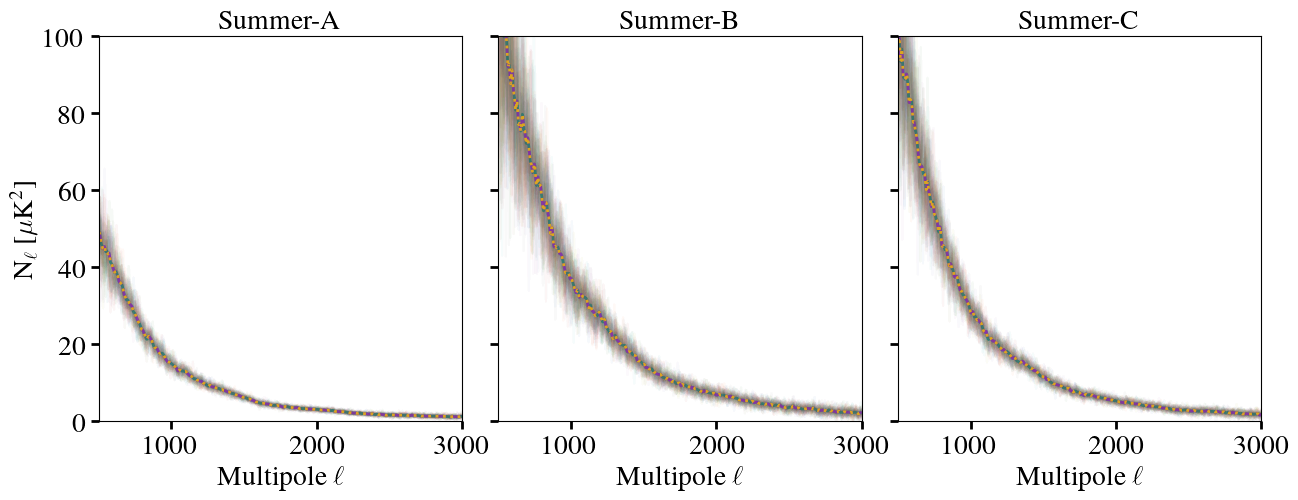

In [18]:
nside=2048
lmax = 2 * nside 
pixwin = hp.pixwin(8192)[:lmax]
expectation_arr = [12, 12, 42]
ls_arr = ['-', '--', ':']

fig, ax_arr = plt.subplots(1, len(field_arr), sharey=True, figsize=(15,5))
plt.subplots_adjust(hspace=0.2, wspace = 0.1)

for cntr, field in enumerate(field_arr):
    for frq_cntr, freq in enumerate(freq_arr):    
        for i in range(1,51):
            cl = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/sims/noise/spectra/%s/full/cls_%sghz_%sghz_seed%s.npy'%(field, 90, 150, i))
            ax_arr[cntr].plot(curr_binned_el, binned_dl_fac * cl, alpha=0.01) 

        curr_binned_nl = np.load('/sptlocal/user/kevinlevy/summerfield_lensing/sims/noise/spectra/%s/full/cls_%sghz_%sghz_avg100.npy'%(field, 90, 150))
        curr_binned_el = np.arange(len(curr_binned_nl))
        
        binned_dl_fac = curr_binned_el * (curr_binned_el+1)/2/np.pi 
        ax_arr[cntr].plot(curr_binned_el, binned_dl_fac * curr_binned_nl, color = color_arr[frq_cntr], ls = ls_arr[frq_cntr], lw=2) 

    
    ax_arr[cntr].set_xlim(500, 3000)
    ax_arr[cntr].set_ylim(0, 100)
    ax_arr[cntr].set_xlabel(r'Multipole $\ell$', fontsize=fontsize)
    ax_arr[cntr].legend(fontsize=fontsize, frameon=False)
    ax_arr[cntr].set_title(title_dic[field], fontsize=fontsize) 
    ax_arr[cntr].tick_params(labelsize = fontsize, length = 6, width = 2)

    if cntr==0:
        ax_arr[cntr].set_ylabel(r'N$_{\ell}$ [$\mu$K$^{2}$]', fontsize=fontsize)
